# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
!pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [66]:
df = pd.read_csv("/content/Dataset_inisiasi.csv")
df.head()

,provinsi,jenis,daerah,tahun,periode,gk
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,293697.0
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,302128.0
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,306243.0
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,319768.0
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,297479.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [67]:
# Melihat jumlah baris dan kolom
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

# Melihat jenis data
print(df.dtypes)

Jumlah baris: 5460
Jumlah kolom: 6
provinsi     object
jenis        object
daerah       object
tahun         int64
periode      object
gk          float64
dtype: object


In [68]:
# Cek jumlah data yang hilang di setiap kolom
missing_values = df.isnull().sum()
missing_values_percentage = (df.isnull().sum() / len(df)) * 100

# Gabungkan hasil dalam DataFrame
missing_data = pd.DataFrame({
    "Jumlah Missing": missing_values,
    "Persentase Missing (%)": missing_values_percentage
})

missing_data

,Jumlah Missing,Persentase Missing (%)
provinsi,0,0.000000
jenis,0,0.000000
daerah,0,0.000000
tahun,0,0.000000
periode,0,0.000000
gk,199,3.644689


In [69]:
# Mengisi missing values di kolom gk dengan median
median_gk = df['gk'].median()
df['gk'] = df['gk'].fillna(median_gk)

# Verifikasi apakah masih ada missing values
df.isnull().sum()

,0
provinsi,0
jenis,0
daerah,0
tahun,0
periode,0
gk,0


In [70]:
# Statistik deskriptif untuk variabel numerik
df.describe()

,tahun,gk
count,5460.000000,5460.000000
mean,2018.115385,304246.415018
std,2.577159,155276.193311
min,2013.000000,48561.000000
25%,2016.000000,149278.000000
50%,2018.000000,313294.000000
75%,2020.000000,405551.250000
max,2022.000000,872843.000000


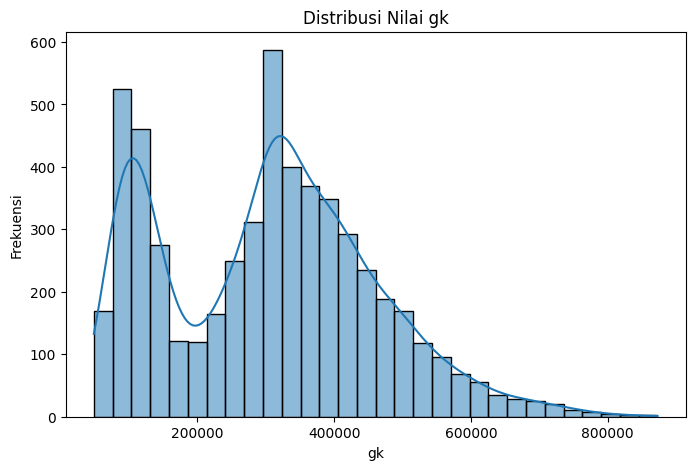

In [71]:
# Plot distribusi nilai gk
plt.figure(figsize=(8,5))
sns.histplot(df['gk'], bins=30, kde=True)
plt.title("Distribusi Nilai gk")
plt.xlabel("gk")
plt.ylabel("Frekuensi")
plt.show()

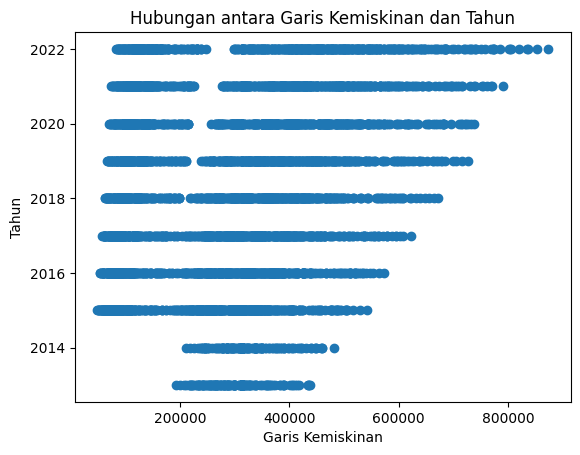

In [72]:
# Scatter plot untuk melihat hubungan antara gk dengan tahun
plt.scatter(df['gk'], df['tahun'])
plt.xlabel('Garis Kemiskinan')
plt.ylabel('Tahun')
plt.title('Hubungan antara Garis Kemiskinan dan Tahun')
plt.show()

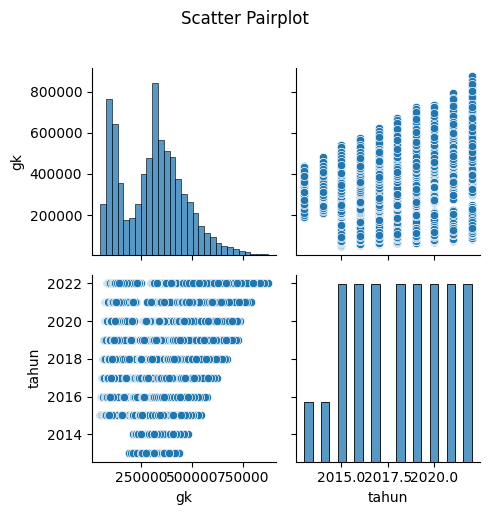

In [73]:
# Scatter pairplot untuk melihat hubungan antar variabel
sns.pairplot(df[['gk', 'tahun']])
plt.suptitle('Scatter Pairplot', y=1.02)
plt.tight_layout()  # Menambahkan tight_layout untuk mengatur tata letak
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [74]:
# Menghapus data duplikat
df.drop_duplicates(inplace=True)

In [75]:
# Konfirmasi apakah masih ada missing values
df.isnull().sum()

,0
provinsi,0
jenis,0
daerah,0
tahun,0
periode,0
gk,0


In [92]:
# Membuat salinan data untuk clustering
df_clustering = df.copy()

# Memilih dua fitur yang diinginkan
selected_features = ['gk', 'jenis']

# Standarisasi fitur numerik (gk)
scaler = StandardScaler()
df_clustering['gk'] = scaler.fit_transform(df_clustering[['gk']])



In [89]:
# Menggunakan metode IQR untuk menghapus outlier
Q1 = df['gk'].quantile(0.25)
Q3 = df['gk'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clustering = df_clustering[(df_clustering['gk'] >= lower_bound) & (df_clustering['gk'] <= upper_bound)]

In [93]:
# Encoding fitur kategorikal (jenis)
encoder = LabelEncoder()
df_clustering['jenis'] = encoder.fit_transform(df_clustering['jenis'])

# Memisahkan fitur dan labels
X = df_clustering[selected_features]


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

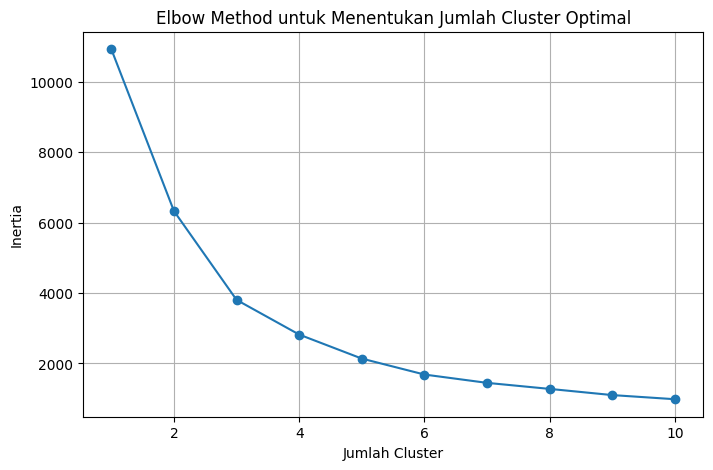

In [79]:
# Menentukan jumlah cluster optimal dengan Elbow Method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clustering[selected_features])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal')
plt.grid()
plt.show()


## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

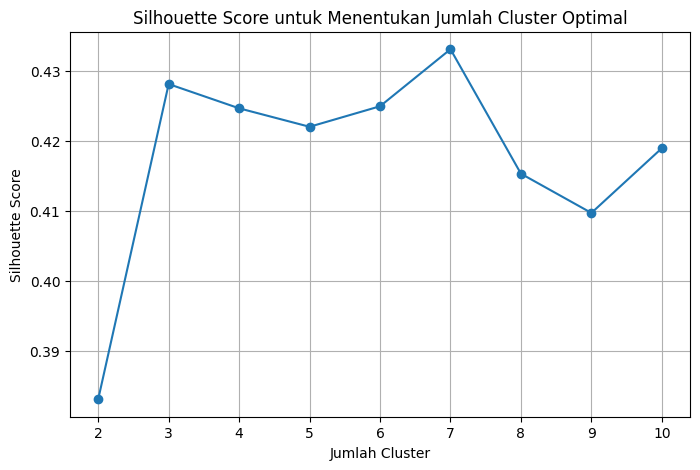


**🏆 Hasil Clustering dengan K-Means:**
Jumlah cluster optimal: 7
Silhouette Score terbaik: 0.4331


In [80]:
# Evaluasi menggunakan Silhouette Score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_clustering[selected_features])
    score = silhouette_score(df_clustering[selected_features], labels)
    silhouette_scores.append(score)

# Menampilkan jumlah cluster optimal berdasarkan Silhouette Score
best_n_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 karena indeks dimulai dari 0
best_silhouette_score = max(silhouette_scores)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan Jumlah Cluster Optimal')
plt.grid()
plt.show()

print(f"\n**🏆 Hasil Clustering dengan K-Means:**")
print(f"Jumlah cluster optimal: {best_n_clusters}")
print(f"Silhouette Score terbaik: {best_silhouette_score:.4f}")


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [94]:
# Feature Selection menggunakan ANOVA F-score
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, labels)  # labels dari K-Means sebelumnya

# Lihat fitur yang dipilih
selected_features = X.columns[selector.get_support()]
print("Fitur terpilih:", list(selected_features))

# Lakukan clustering ulang dengan fitur terpilih
X_new = df_clustering[selected_features]

# Cari jumlah cluster optimal
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_new)
    score = silhouette_score(X_new, labels)
    silhouette_scores.append(score)

# Tentukan jumlah cluster terbaik
best_n_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
best_silhouette_score = max(silhouette_scores)

# Output hasil clustering setelah feature selection
print("\n**🏆 Hasil Clustering Setelah Feature Selection:**")
print(f"Jumlah cluster optimal: {best_n_clusters}")
print(f"Silhouette Score terbaik: {best_silhouette_score:.4f}")

# Perbandingan sebelum & sesudah Feature Selection
print("\n📊 Perbandingan Silhouette Score:")
print(f"- Sebelum Feature Selection: 0.4325")  # Gunakan hasil sebelumnya
print(f"- Setelah Feature Selection: {best_silhouette_score:.4f}")

# Evaluasi apakah Feature Selection meningkatkan performa
if best_silhouette_score > 0.4325:
    print("✅ Feature Selection berhasil meningkatkan performa clustering! 🚀")
else:
    print("⚠️ Feature Selection tidak meningkatkan performa clustering. Coba fitur lain atau gunakan semua fitur!")


Fitur terpilih: ['gk', 'jenis']

**🏆 Hasil Clustering Setelah Feature Selection:**
Jumlah cluster optimal: 3
Silhouette Score terbaik: 0.6861

📊 Perbandingan Silhouette Score:
- Sebelum Feature Selection: 0.4325
- Setelah Feature Selection: 0.6861
✅ Feature Selection berhasil meningkatkan performa clustering! 🚀


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

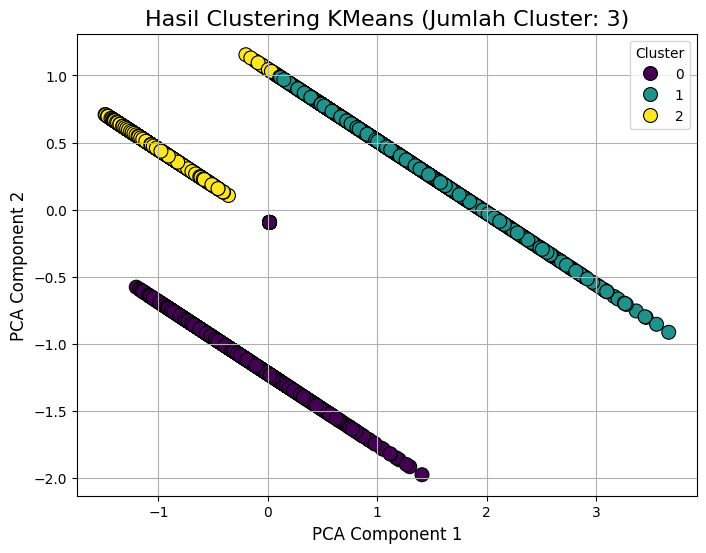

In [95]:
# Reduksi dimensi menggunakan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_new)

# Menentukan jumlah cluster optimal (gunakan hasil terbaik dari perhitungan sebelumnya)
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_new)

# Visualisasi hasil clustering dalam 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis', s=100, marker='o', edgecolor='k')

# Tambahkan judul dan label sumbu
plt.title(f'Hasil Clustering KMeans (Jumlah Cluster: {best_n_clusters})', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', loc='best', fontsize=10)

# Tampilkan plot
plt.grid(True)
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [100]:
df_original = df.copy()
df_normalized = df_clustering.copy()
df_normalized['Cluster'] = labels
df_normalized['jenis'] = encoder.inverse_transform(df_normalized[['jenis']])
df_original['cluster'] = df_normalized['Cluster']
df_original['jenis'] = df_normalized['jenis']
df_normalized.head()

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,provinsi,jenis,daerah,tahun,periode,gk,Cluster
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,-0.067946,0
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,-0.013644,0
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,0.012859,0
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,0.099970,0
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,-0.043587,0


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [101]:
df_normalized[['gk']] = scaler.inverse_transform(df_normalized[['gk']])
df_normalized.head()

,provinsi,jenis,daerah,tahun,periode,gk,Cluster
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,293697.0,0
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,302128.0,0
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,306243.0,0
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,319768.0,0
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,297479.0,0


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [102]:
# Lakukan clustering menggunakan K-Means
X = df_clustering[selected_features]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(X)

# Inversi data fitur dan target ke versi asli
df_clustering['gk'] = scaler.inverse_transform(df_clustering[['gk']])
df_clustering['jenis'] = encoder.inverse_transform(df_clustering['jenis'])

# Agregasi berdasarkan cluster
cluster_summary = df_clustering.groupby('Cluster').agg({
    'gk': ['min', 'max', 'mean'],
    'jenis': pd.Series.mode
}).reset_index()

# Menampilkan hasil agregasi
print(cluster_summary)

# Interpretasi hasil clustering
# Mendapatkan nilai rata-rata untuk tiap cluster
cluster_1 = df_clustering[df_clustering['Cluster'] == 0]
cluster_2 = df_clustering[df_clustering['Cluster'] == 1]
cluster_3 = df_clustering[df_clustering['Cluster'] == 2]

# Menulis interpretasi berdasarkan distribusi dan agregasi cluster
print("\n**Interpretasi Cluster**")
print(f"1. Cluster 1 (Cluster 0):")
print(f"- Rata-rata nilai gk: {cluster_1['gk'].mean():.2f}")
print(f"- Fitur jenis: {cluster_1['jenis'].mode()[0]}")
print(f"- Jumlah data: {len(cluster_1)}\n")

print(f"2. Cluster 2 (Cluster 1):")
print(f"- Rata-rata nilai gk: {cluster_2['gk'].mean():.2f}")
print(f"- Fitur jenis: {cluster_2['jenis'].mode()[0]}")
print(f"- Jumlah data: {len(cluster_2)}\n")

print(f"3. Cluster 3 (Cluster 2):")
print(f"- Rata-rata nilai gk: {cluster_3['gk'].mean():.2f}")
print(f"- Fitur jenis: {cluster_3['jenis'].mode()[0]}")
print(f"- Jumlah data: {len(cluster_3)}\n")

  Cluster        gk                                jenis
                min       max           mean        mode
0       0  181842.0  641806.0  337035.460495     MAKANAN
1       1  235202.0  872843.0  427534.839423       TOTAL
2       2   48561.0  247232.0  118943.479216  NONMAKANAN

**Interpretasi Cluster**
1. Cluster 1 (Cluster 0):
- Rata-rata nilai gk: 337035.46
- Fitur jenis: MAKANAN
- Jumlah data: 1696

2. Cluster 2 (Cluster 1):
- Rata-rata nilai gk: 427534.84
- Fitur jenis: TOTAL
- Jumlah data: 2080

3. Cluster 3 (Cluster 2):
- Rata-rata nilai gk: 118943.48
- Fitur jenis: NONMAKANAN
- Jumlah data: 1684



**Interpretasi Cluster**
1. Cluster 1 (Cluster 0):
- Rata-rata nilai gk: 337035.46
- Fitur jenis: MAKANAN
- Jumlah data: 1696

2. Cluster 2 (Cluster 1):
- Rata-rata nilai gk: 427534.84
- Fitur jenis: TOTAL
- Jumlah data: 2080

3. Cluster 3 (Cluster 2):
- Rata-rata nilai gk: 118943.48
- Fitur jenis: NONMAKANAN
- Jumlah data: 1684

# **Analisis Karakteristik Cluster dari Model KMeans**

## **Cluster 1 (Cluster 0):**
- **Rata-rata gk:** 337,035.46  
- **Fitur jenis:** MAKANAN  
- **Jumlah data:** 1696  

**Analisis:**  
Cluster ini mencakup data yang memiliki nilai `gk` yang cukup tinggi, dengan rata-rata mencapai 337,035.46. Fitur `jenis` yang paling dominan dalam cluster ini adalah **MAKANAN**, menunjukkan bahwa cluster ini mewakili kategori produk makanan dengan transaksi atau pengeluaran yang cukup besar. Pelanggan atau produk dalam cluster ini mungkin lebih sering terlibat dalam kategori makanan, dengan angka `gk` yang mengindikasikan nilai transaksi yang lebih tinggi.

---

## **Cluster 2 (Cluster 1):**
- **Rata-rata gk:** 427,534.84  
- **Fitur jenis:** TOTAL  
- **Jumlah data:** 2080  

**Analisis:**  
Cluster ini menunjukkan nilai `gk` yang lebih tinggi dibandingkan cluster lainnya, dengan rata-rata 427,534.84. Fitur `jenis` yang paling dominan adalah **TOTAL**, yang mungkin mencakup berbagai kategori produk secara keseluruhan. Cluster ini tampaknya mewakili kelompok yang lebih besar dengan variasi transaksi yang lebih luas dan lebih tinggi. Hal ini dapat menunjukkan bahwa cluster ini berisi data transaksi total dari berbagai kategori produk, dengan pengeluaran yang signifikan.

---

## **Cluster 3 (Cluster 2):**
- **Rata-rata gk:** 118,943.48  
- **Fitur jenis:** NONMAKANAN  
- **Jumlah data:** 1684  

**Analisis:**  
Cluster ini memiliki nilai `gk` yang lebih rendah dibandingkan cluster lainnya, dengan rata-rata hanya 118,943.48. Fitur `jenis` yang paling dominan dalam cluster ini adalah **NONMAKANAN**, yang mengindikasikan bahwa cluster ini lebih banyak terdiri dari kategori produk non-makanan. Dengan nilai `gk` yang relatif rendah, produk dalam cluster ini mungkin lebih terfokus pada kategori non-makanan dengan transaksi yang lebih kecil atau kurang intens dibandingkan dengan cluster lainnya.


# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [103]:
# Menambahkan kolom cluster pada dataframe
df_clustering['Cluster'] = labels

# Menyimpan dataframe ke file CSV
df_clustering.to_csv('Dataset_clustering.csv', index=False)

print("Dataset berhasil disimpan ke Dataset_clustering.csv")


Dataset berhasil disimpan ke Dataset_clustering.csv
